Downloading...
From: https://drive.google.com/uc?id=1AWIo1hKcSfit_0oF0lT0EyiYmvi1iSZb
To: /content/archive.zip
100%|██████████| 19.5k/19.5k [00:00<00:00, 31.1MB/s]


Shape: (1000, 16)
             age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.0000           1000.00000         1000.000000    1000.000000   
mean     20.4980              3.55010            2.505500       1.819700   
std       2.3081              1.46889            1.172422       1.075118   
min      17.0000              0.00000            0.000000       0.000000   
25%      18.7500              2.60000            1.700000       1.000000   
50%      20.0000              3.50000            2.500000       1.800000   
75%      23.0000              4.50000            3.300000       2.525000   
max      24.0000              8.30000            7.200000       5.400000   

       attendance_percentage  sleep_hours  exercise_frequency  \
count            1000.000000  1000.000000         1000.000000   
mean               84.131700     6.470100            3.042000   
std                 9.399246     1.226377            2.025423   
min                56.000000     3.20

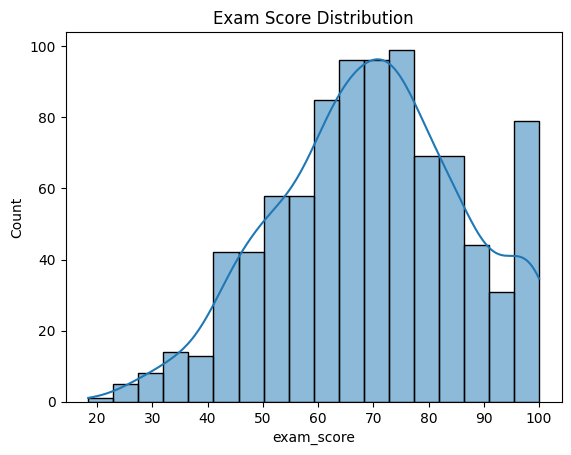

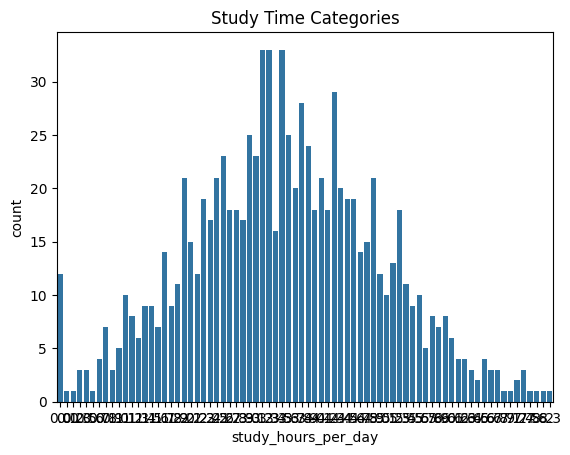

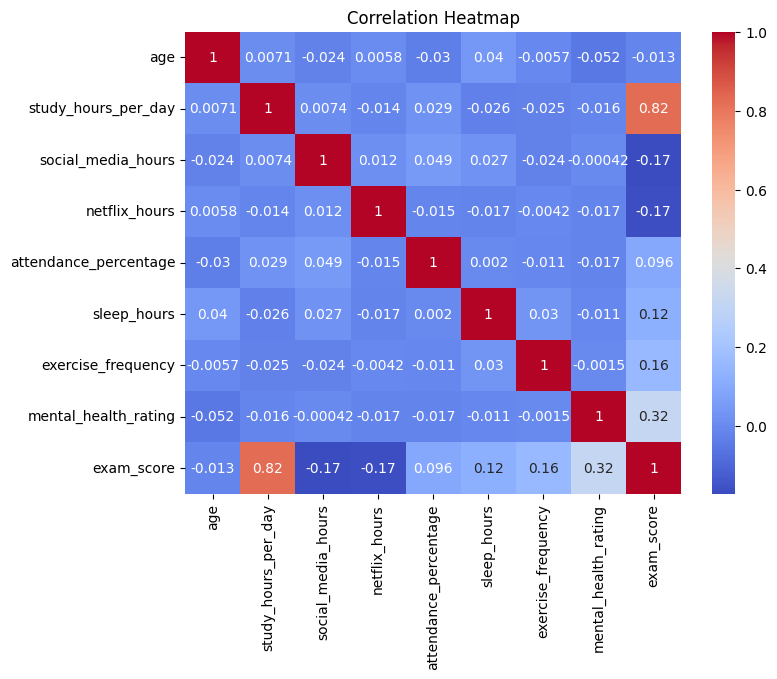

Linear Regression RMSE: 8.83897290570293
Random Forest RMSE: 9.696473253453801
R² (Linear): 0.7121667963488889
R² (RF): 0.6536103604199662
KNN RMSE: 10.320489181598754


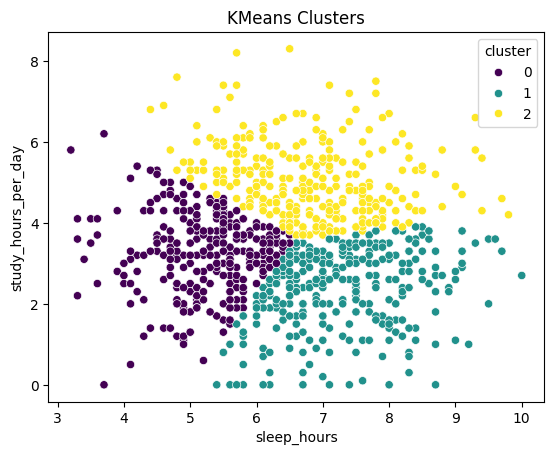

In [18]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

!pip install -q gdown
import gdown

file_id = "1AWIo1hKcSfit_0oF0lT0EyiYmvi1iSZb"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, 'archive.zip', quiet=False)

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv('student_habits_performance.csv', encoding='ISO-8859-1')

# step Two
print("Shape:", df.shape)
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("Columns:", df.columns.tolist())

# Drop missing
df = df.dropna()

# Visuals
sns.histplot(df['exam_score'], kde=True)
plt.title('Exam Score Distribution')
plt.show()

sns.countplot(x='study_hours_per_day', data=df)
plt.title('Study Time Categories')
plt.show()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#step Three
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df[['sleep_hours', 'study_hours_per_day', 'attendance_percentage']]
y = df['exam_score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# R² Scores
print("R² (Linear):", r2_score(y_test, y_pred_lr))
print("R² (RF):", r2_score(y_test, y_pred_rf))

# KNN
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))

#step Four -clustering

from sklearn.cluster import KMeans

X_cluster = df[['sleep_hours', 'study_hours_per_day']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

sns.scatterplot(x='sleep_hours', y='study_hours_per_day', hue='cluster', data=df, palette='viridis')
plt.title('KMeans Clusters')
plt.show()
